In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from pathlib import Path
import sys, os
sys.path.append(str(Path(os.getcwd()).parent))
from tqdm import tqdm

from src.model.loss import RSSMLoss
from src.dataset import E2CDataset
from src.model.rssm import RSSME2C
from IPython.display import display, clear_output
from collections import defaultdict
import random
import cv2

/home/ayush/Desktop/sawyer_moveit_ws/src/E2C/src/dataset.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(dataset_dir / dataset_file)


16200


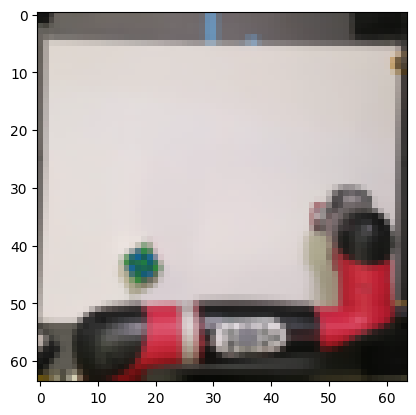

In [2]:
# Load Dataset
# yaml file to pass, which just has dataset name, etc
config_file = Path(os.getcwd()) / "../config/bobcat_9.yaml"
with open(config_file, 'r') as f:
    config = yaml.safe_load(f)
dataset = E2CDataset(config)
config['vae']['in_image_shape'] = dataset.in_img_shape
num_out_channels = config['vae']['in_image_shape'][0] // config['trans']['past_length']    # Output only single frame
config['vae']['out_image_shape'] = (num_out_channels, *config['vae']['in_image_shape'][1:])     
config['trans']['control_size'] = dataset.U.shape[-1]
batch_size = config['train']['batch_size']
# split dataset into train and val
# take half the dataset for now, for faster training
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
print(len(train_dataset))
plt.imshow(cv2.cvtColor(dataset.X[0,0].permute(1,2,0).numpy(), cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
# device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
# print(device)
# enc_latent_size = 128
# stochastic_size = 64
# deterministic_size = 128
# vae = {}
# vae.update(
#     { 'in_image_shape': (9, 64, 64),
#       'out_image_shape': (3, 64, 64),
#       'enc_latent_size': 256,
#       'enc_kernel_size': 3,
#       'dec_kernel_size': 4,
#       'stride': 2,
#       'pad': 1,
#     }
# )
# loss_params = config['loss']
# loss_params.update(
#     {
#       'kld_anneal_mode': 'reverse',
#       'recon_mult': 3e3,
#       'beta': 1e-4,
#     }
# )

# batch_size = 128
# num_rollout_steps = 180 # can decrease this
# num_epochs = 100
# num_batches = 100
# buffer_capacity = 2000
# learning_rate = 2e-4

In [4]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
enc_latent_size = 256
stochastic_size = 32
deterministic_size = 128
vae = {}
vae.update(
    { 'in_image_shape': (9, 64, 64),
      'out_image_shape': (3, 64, 64),
      'enc_latent_size': 256,
      'enc_kernel_size': 3,
      'dec_kernel_size': 4,
      'stride': 2,
      'pad': 1,
    }
)
loss_params = config['loss']
loss_params.update(
    {
      'kld_anneal_mode': 'linear',
      'recon_mult': 3e3,
      'beta': 7e-6,
    }
)

batch_size = 128
num_rollout_steps = 180 # can decrease this
num_epochs = 100
num_batches = 50
buffer_capacity = 2000
learning_rate = 1e-4

cuda:1


In [5]:
model = RSSME2C(
    enc_latent_size = vae['enc_latent_size'],
    stochastic_size = stochastic_size,
    deterministic_size=deterministic_size,
    control_size = config['trans']['control_size'],
    past_length = config['trans']['past_length'],
    pred_length=config['trans']['pred_length'],
    conv_params=vae,
    device=device,
    output_uncertainty=True
).to(device)
loss_fn = RSSMLoss(num_epochs=2*num_epochs, loss_params=loss_params)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=config['trans']['weight_decay'])

plot_history = {}

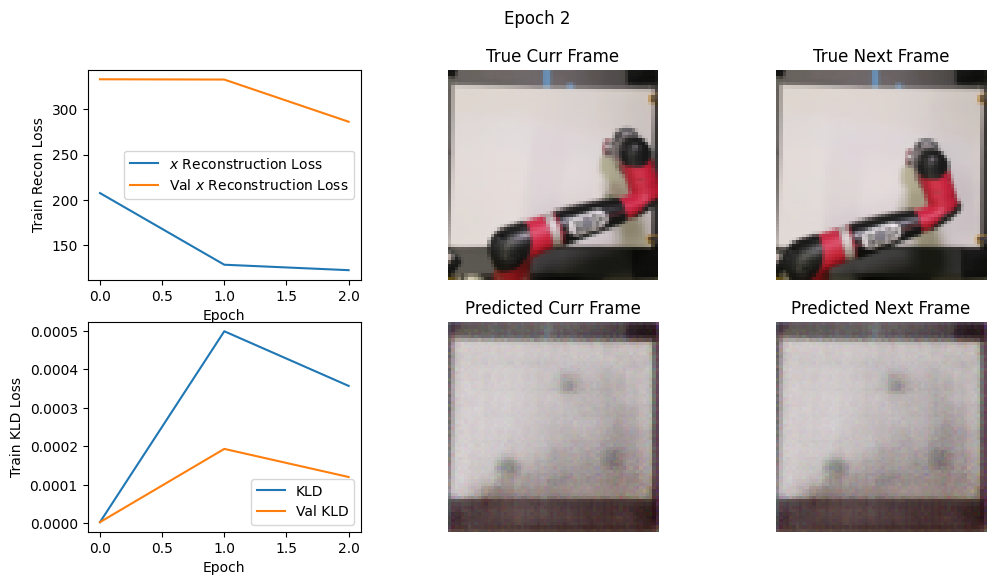

Training:   3%|▎         | 3/100 [00:44<24:10, 14.95s/it, Epoch=3, Epoch Loss=53.2954]

KeyboardInterrupt: 

In [6]:
plot_history = defaultdict(list)
plot_epochs = []

def plot_reconstruction(fig, ax, tr, loss_terms, val_loss_dict, epoch):
    if not plot_epochs or plot_epochs[-1] != epoch:
        plot_epochs.append(epoch)

    for key, val in loss_terms.items():
        plot_history[key].append(val)
    for key, val in val_loss_dict.items():
        plot_history[key].append(val)

    ax[0, 0].clear()
    ax[1, 0].clear()
    for idx, tup in enumerate(plot_history.items()):
        key, vals = tup
        if key.__contains__("Reconstruction"):
            ax[0, 0].plot(plot_epochs, vals, label=key)
        elif key.__contains__("KLD"):
            ax[1, 0].plot(plot_epochs, vals, label=key)
    ax[0, 0].set_xlabel("Epoch")
    ax[0, 0].set_ylabel("Train Recon Loss")
    ax[0, 0].legend()

    ax[1, 0].set_xlabel("Epoch")
    ax[1, 0].set_ylabel("Train KLD Loss")
    ax[1, 0].legend()

    ax[0, 1].clear()
    ax[0, 1].imshow(cv2.cvtColor(np.transpose(tr['x'][0, 0].detach().cpu().numpy(), (1, 2, 0)), cv2.COLOR_BGR2RGB))
    ax[0, 1].set_title("True Curr Frame")
    ax[0, 1].axis("off")

    ax[1, 1].clear()
    ax[1, 1].imshow(cv2.cvtColor(np.transpose(tr['x_recon'][0].detach().cpu().numpy(), (1, 2, 0)), cv2.COLOR_BGR2RGB))
    ax[1, 1].set_title("Predicted Curr Frame")
    ax[1, 1].axis("off")

    ax[0, 2].clear()
    ax[0, 2].imshow(cv2.cvtColor(np.transpose(tr['x_next'][0, 0].detach().cpu().numpy(), (1, 2, 0)), cv2.COLOR_BGR2RGB))
    ax[0, 2].set_title("True Next Frame")
    ax[0, 2].axis("off")

    ax[1, 2].clear()
    ax[1, 2].imshow(cv2.cvtColor(np.transpose(tr['x_pred'][0, 0].detach().cpu().numpy(), (1, 2, 0)), cv2.COLOR_BGR2RGB))
    ax[1, 2].set_title("Predicted Next Frame")
    ax[1, 2].axis("off")

    fig.suptitle(f"Epoch {epoch}")
    plt.pause(0.01)

recon_losses, kld_losses = [], []
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# line_mse, = axs[0].plot(recon_losses, label='MSE', color='blue')
# line_kld, = axs[1].plot(kld_losses, label='KLD', color='orange')

# plt.tight_layout()
# plt.show()

# Training loop
epoch_loss = 0.0
pbar = tqdm(range(num_epochs), desc="Training")
for epoch in pbar:
    total_loss = 0.0

    for batch_idx in range(0, num_batches):
        # Send training data to GPU
        x, x_next, u = dataset[random.sample(range(min((epoch+1)*num_rollout_steps, len(dataset))), min(batch_size, num_rollout_steps))]
        x, x_next, u = x.to(device), x_next.to(device).to(torch.float32), u.to(device).to(torch.float32)
        x = x.reshape(x.shape[0], -1, *vae['out_image_shape']).to(torch.float32)    # Stack obs history in channel dim

        # Forward pass
        train_return = model(x, x_next, u)
        train_return['x'] = x
        train_return['x_next'] = x_next

        # Compute loss and backprop
        if torch.isnan(train_return['x_pred']).any(): print('NaN detected in x_pred')
        # print(x.shape, x_next.shape, train_return['x_recon'].shape, train_return['x_pred'].shape)
        # for keys, items in train_return.items():
        #     print(f"{keys}: {items.shape if torch.is_tensor(items) else type(items)}")
        loss, loss_return = loss_fn(train_return, epoch)
        # recon_losses.append(loss_return[r"$x$ Reconstruction Loss"])
        # kld_losses.append(loss_return["KLD"])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if torch.isnan(loss):
            print("NaN loss encountered, stopping training.")
            break

        total_loss += loss.item() * x.size(0)   # Aggregate total epoch loss

    val_loss_dict = {}
    # TODO: Also plot validation loss only
    # if (epoch) % 10 == 0:
    model.eval()
    for (x_val, x_next_val, u_val) in val_loader:
        x_val, x_next_val, u_val = x_val.to(device), x_next_val.to(device).to(torch.float32), u_val.to(device).to(torch.float32)
        x_val = x_val.reshape(x_val.shape[0], -1, *vae['out_image_shape']).to(torch.float32)    # Stack obs history in channel dim

        # Forward pass
        val_return = model(x_val, x_next_val, u_val)
        val_return['x'] = x_val
        val_return['x_next'] = x_next_val

        # Compute loss
        if torch.isnan(val_return['x_pred']).any(): print('NaN detected in x_pred')
        val_loss, val_loss_return = loss_fn(val_return, epoch)
    
    for keys, vals in val_loss_return.items():
        val_loss_dict[f"Val {keys}"] = vals
    model.train()

    # Display average loss for the epoch
    epoch_loss = total_loss / len(train_loader.dataset)

    plot_reconstruction(fig, axs, train_return, loss_return, val_loss_dict, epoch)
    # --- update display ---
    clear_output(wait=True)
    display(fig)
    plt.pause(0.01)

    
    pbar.set_postfix({
        'Epoch': epoch+1,
        'Epoch Loss': f"{epoch_loss:.4f}"})
pbar.close()

plt.show() 

In [ ]:
torch.save(model.state_dict(), 'rssm_pretrain_model.pt')

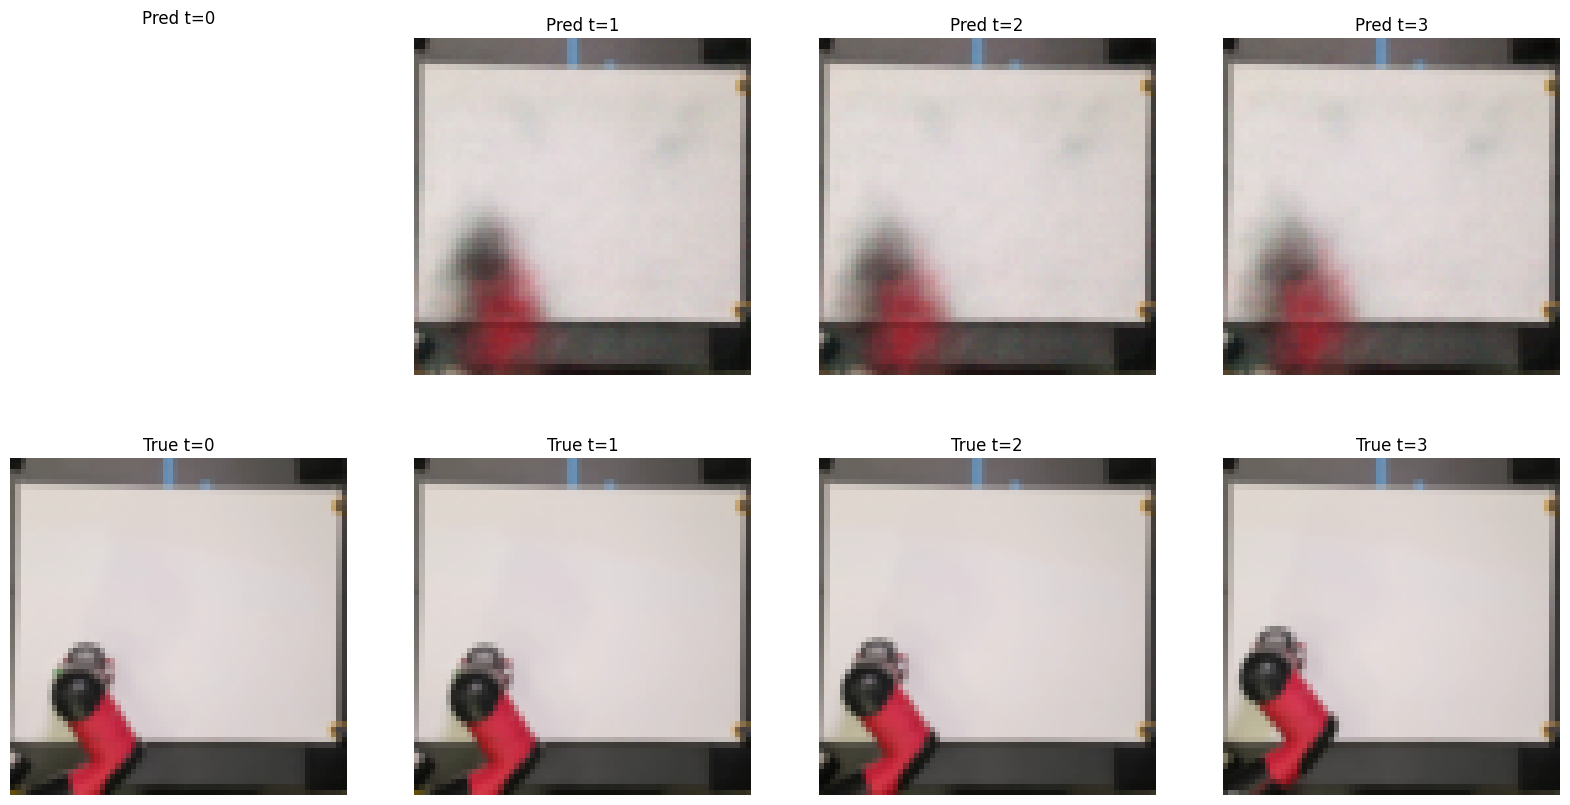

In [ ]:
past_length = config['trans']['past_length']
pred_len = config['trans']['pred_length']
dtype = next(model.parameters()).dtype

model.eval()
x, x_next, u = dataset[random.sample(range(train_size), batch_size)]
x, x_next, u = x[-1].to(device), x_next[-1].to(device), u[-1].to(device)

window = x.unsqueeze(0).to(device)
action_seq = u

mu_prior, log_var_prior, zs = model.encode_posterior(window)
h = torch.zeros(model.num_layers, 1, model.deterministic_size, device=device, dtype=dtype)
z = zs[:, -1]
if model.output_uncertainty:
    x_recon, x_pred_uncertainty = model.decoder(z)
else:
    x_recon = model.decoder(z)
x_recon_next = []
for act in action_seq:
    act_batch = act.view(1, -1).to(device, dtype=dtype)
    h, z_prior, mu_p, log_var_p = model.rssm_step(h, z.unsqueeze(1), act_batch)
    # h, z_prior, mu_p, log_var_p = trainer.model.rssm_step(h, zs, act_batch)
    # Decode prior to observation space
    if model.output_uncertainty:
        x_pred, x_pred_uncertainty = model.decoder(z_prior)
    else:
        x_pred = model.decoder(z_prior)
    x_recon_next.append(x_pred.detach().cpu().to(torch.float32))
    
    if past_length > 1:
        window_frames = window[:, 1:]   # drop first frame
        window = torch.cat([window_frames, x_pred.unsqueeze(1).detach()], dim=1)
    else:
        window = x_pred.detach()  # past_length==1, just use pred image
    mu_q, log_var_q, zs = model.encode_posterior(window)
    z = zs[:, -1]

    # Posterior from updated observation window
    # enc = trainer.model.encoder(x_pred)
    # # stats = trainer.model.post(torch.cat([enc, h[-1]], dim=-1))
    # stats = trainer.model.post(enc)
    # mu_q, log_var_q = stats.chunk(2, dim=-1)
    # z = trainer.model.reparameterize(mu_q, log_var_q)

# Build visualization grid: 2 rows, (pred_len + 1) columns
cols = pred_len + 1
fig, ax = plt.subplots(2, cols, figsize=(5 * cols, 10))
ax = np.atleast_2d(ax)
ax[0, 0].set_title(f"Pred t=0")
ax[1, 0].set_title(f"True t=0")
for j in range(1, cols):
    ax[0, j].set_title(f"Pred t={j}")
    ax[1, j].set_title(f"True t={j}")

ims = []
# Plot frames
ims.clear()
ax[1, 0].imshow(cv2.cvtColor(x[-1].detach().cpu().squeeze(0).permute(1, 2, 0).numpy(), cv2.COLOR_BGR2RGB))
for j in range(1, cols):
    ims.append(ax[0, j].imshow(cv2.cvtColor(x_recon_next[j-1].detach().cpu().squeeze(0).permute(1, 2, 0).numpy(), cv2.COLOR_BGR2RGB)))
    ims.append(ax[1, j].imshow(cv2.cvtColor(x_next[j-1].detach().cpu().squeeze(0).permute(1, 2, 0).numpy(), cv2.COLOR_BGR2RGB)))
for a in ax.flatten():
    a.axis('off')
plt.show()